In [ ]:
## Import Modules & Initialize Randomization ##
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.fft as fft

# Initialize the random number generator with a fixed seed for reproducible results
rng = np.random.default_rng(seed=42)

In [2]:
## Define the Mathematical Signal & Noise Framework
# 1. Establish the temporal domain and sampling parameters (fs , t)
fs = 500 # Sampling frequency in Hz
t = np.linspace(0, 5, fs*5, endpoint=False)  # 5 seconds duration

# 2. Synthesize the clean fundamental ECG waveform structure (clean_ecg) as a composite of multiple sinusoidal components to mimic the PQRST complex
clean_ecg = (np.sin(2 * np.pi * 1 * t) 
             + 0.5 * np.sin(2 * np.pi * 3 * t)
             + 0.2 * np.sin(2 * np.pi * 7 * t)) 

# 3. Synthesize the specific noise components
baseline_drift = 0.8 * np.sin(2 * np.pi * 0.3 * t) # 0.3 Hz baseline wander
powerline_hum = 0.4 * np.sin(2 * np.pi * 50 * t)   #50Hz powerline grid hum
muscle_noise = 0.2 * rng.normal(size=t.size)       #High-frequency random tremor

# 4. Superimpose all components into a single corrupted raw ECG signal (raw_ecg)
raw_ecg = clean_ecg + baseline_drift + powerline_hum + muscle_noise

In [3]:
## Compute Spectral Domain Metrics (FFT Analysis)
# 1. Compute the Fast Fourier Transform (FFT) amplitudes
fft_vals = fft.fft(raw_ecg)
frequencies = fft.fftfreq(len(raw_ecg), d=1/fs)

# 2. Isolate the positive half of the frequency spectrum (one-sided FFT)
pos_mask = frequencies >=0
fft_mags = np.abs(fft_vals)[pos_mask]
freqs_side = frequencies[pos_mask]

In [5]:
## Design and Implement the 4th order Butterworth Bandpass Filter
# 1. Normalize cutoff frequencies relative to the Nyquist frequency
nyquist = 0.5 * fs
low_cutoff = 0.5 / nyquist
high_cutoff = 40 / nyquist

# 2. Calculate the filter's transfer function coefficients (b, a)
b, a = signal.butter(N=4, Wn=[low_cutoff, high_cutoff], btype='bandpass')

#3. Apply the designed filter to the raw ECG signal using zero-phase filtering to maintain peak allignment (filtered_ecg)
filtered_ecg = signal.filtfilt(b, a, raw_ecg)

In [6]:
## Feature Extraction (R-Peak Detection)
#Identify individual heartbeats by isolating localized voltage maxima (R-peaks) in the filtered ECG signal
#distance = fs*0.6 ensures a logical maximum heart rate barrier of 100 bpm (60/0.6 = 100)
peaks, _ = signal.find_peaks(filtered_ecg, distance=int(fs*0.6), prominence=0.4)

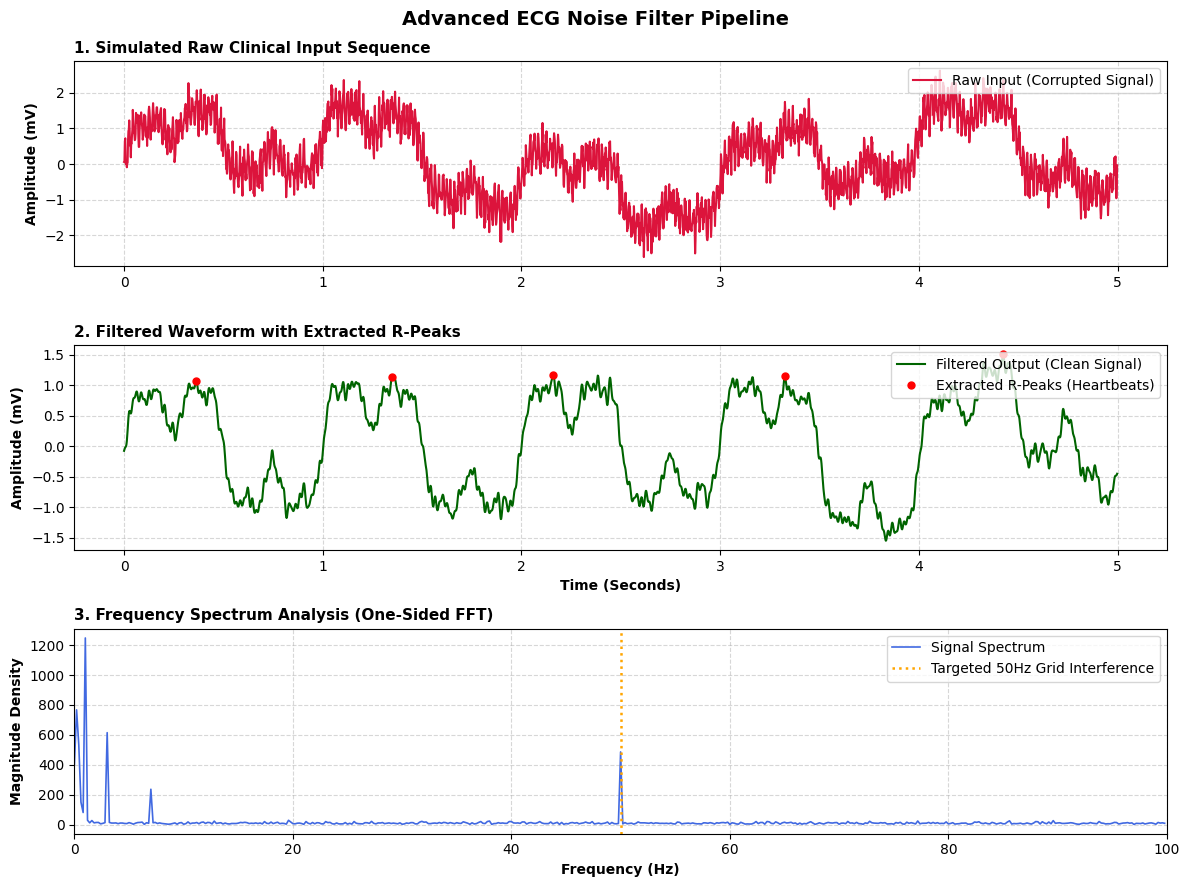

In [10]:
## Generate the Multi-Axis Visualization
# 1- Initialize a 3-raw subplot figure with shared x-axes for alignment
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(12, 9))
fig.suptitle('Advanced ECG Noise Filter Pipeline', fontsize=14, fontweight='bold')

# 2- Plot A: The raw ECG signal with all noise components
ax1.plot(t, raw_ecg, color= 'crimson', label = 'Raw Input (Corrupted Signal)')
ax1.set_ylabel('Amplitude (mV)', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')
ax1.set_title('1. Simulated Raw Clinical Input Sequence', fontsize=11, loc='left', fontweight='bold')

# 3- Plot B: The filtered output data with explicit feature extraction markers
ax2.plot(t, filtered_ecg, color='darkgreen', linewidth=1.5, label='Filtered Output (Clean Signal)')
ax2.plot(t[peaks], filtered_ecg[peaks], 'ro', markersize=5, label='Extracted R-Peaks (Heartbeats)')
ax2.set_ylabel('Amplitude (mV)', fontweight='bold')
ax2.set_xlabel('Time (Seconds)', fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')
ax2.set_title('2. Filtered Waveform with Extracted R-Peaks', fontsize=11, loc='left', fontweight='bold')

# 4- Plot C: The Frequency Domain verification graph exposing the hidden noise spikes
ax3.plot(freqs_side[:fs], fft_mags[:fs], color='royalblue', linewidth=1.2, label='Signal Spectrum')
ax3.axvline(x=50, color='orange', linestyle=':', linewidth=1.8, label='Targeted 50Hz Grid Interference')
ax3.set_title('3. Frequency Spectrum Analysis (One-Sided FFT)', fontsize= 11, loc='left', fontweight='bold')
ax3.set_ylabel('Magnitude Density', fontweight='bold')
ax3.set_xlabel('Frequency (Hz)', fontweight='bold')
ax3.set_xlim(0, 100)  #Constrain ciew to look closely at noise boundaries
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()